# **see the results**

In [7]:
base_results = {
    "api framework": "data/output/suggest_library_py_api.json",
    "data visualisation": "data/output/suggest_library_py_vis.json",
    "database adapter": "data/output/suggest_library_py_dba.json",
    "distributed computing": "data/output/suggest_library_py_dist.json",
}

exp_results = {
    "api framework": "data/output/suggest_library_exp_py_api.json",
    "data visualisation": "data/output/suggest_library_exp_py_vis.json",
    "database adapter": "data/output/suggest_library_exp_py_dba.json",
    "distributed computing": "data/output/suggest_library_exp_py_dist.json",
}

In [8]:
from src.output import read_json

base_data = {}
for _type, _file in base_results.items():
    _data = read_json(file_path=_file)
    base_data[_type] = list(_data["results"]["gpt-4o-mini"]["suggestions"].values())

print(base_data)

exp_data = {}
for _type, _file in exp_results.items():
    _data = read_json(file_path=_file)
    exp_data[_type] = list(_data["results"]["gpt-4o-mini"]["suggestions"].values())

print(exp_data)

{'api framework': [9891, 106, 3], 'data visualisation': [9992, 7, 1], 'database adapter': [10000], 'distributed computing': [9995, 5]}
{'api framework': [10000], 'data visualisation': [9695, 294, 6, 2, 2, 1], 'database adapter': [9784, 152, 41, 19, 2, 1, 1], 'distributed computing': [8274, 1726]}


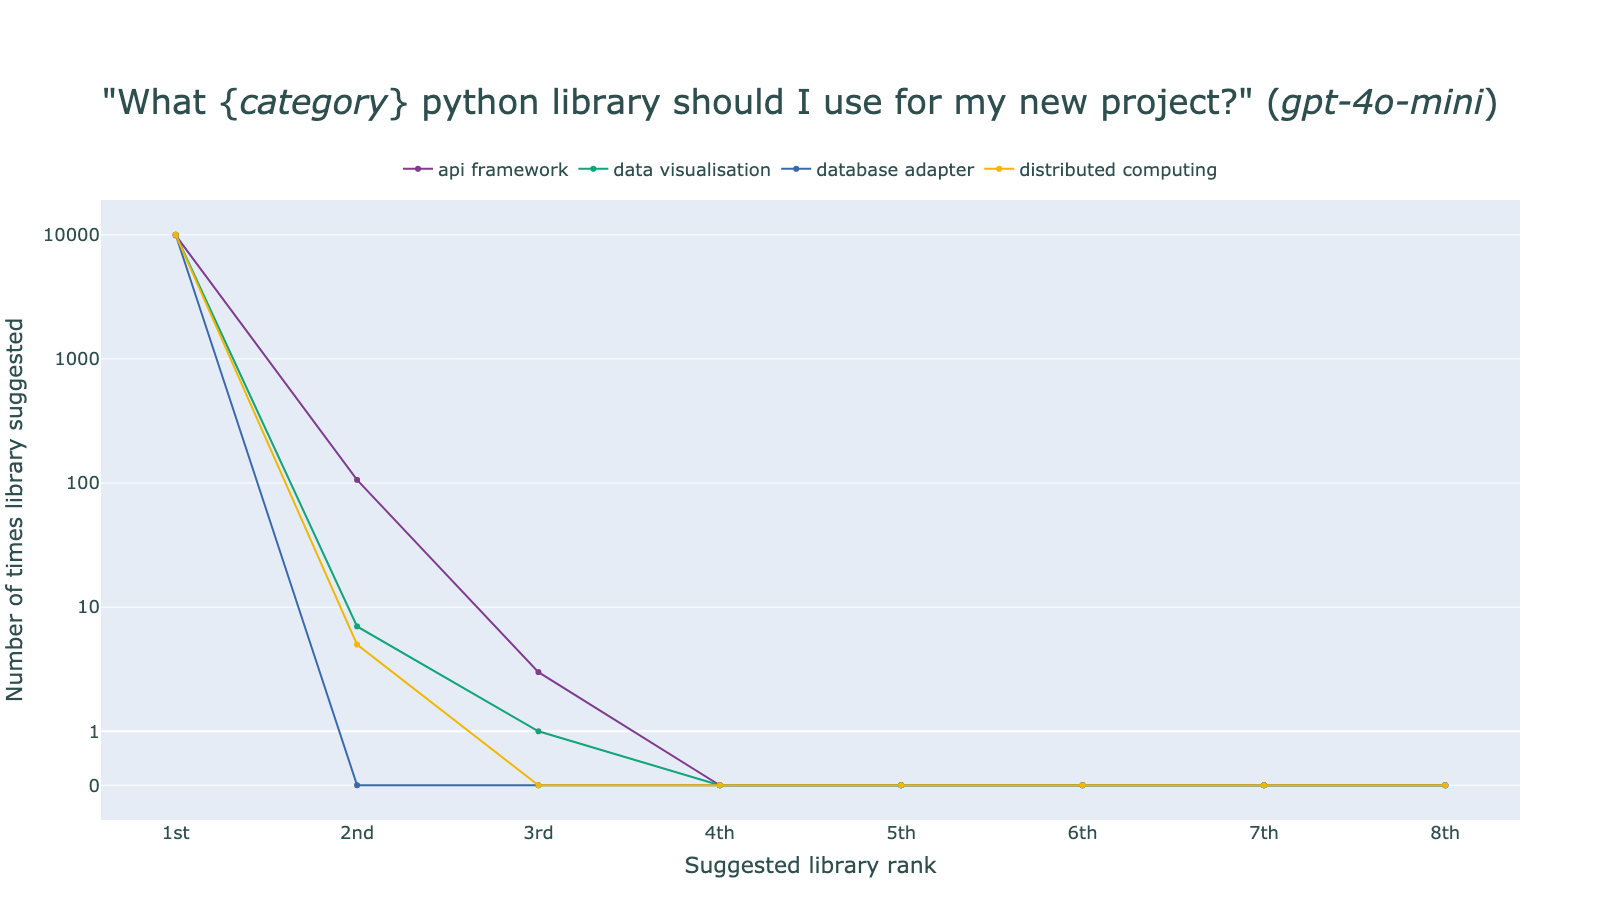

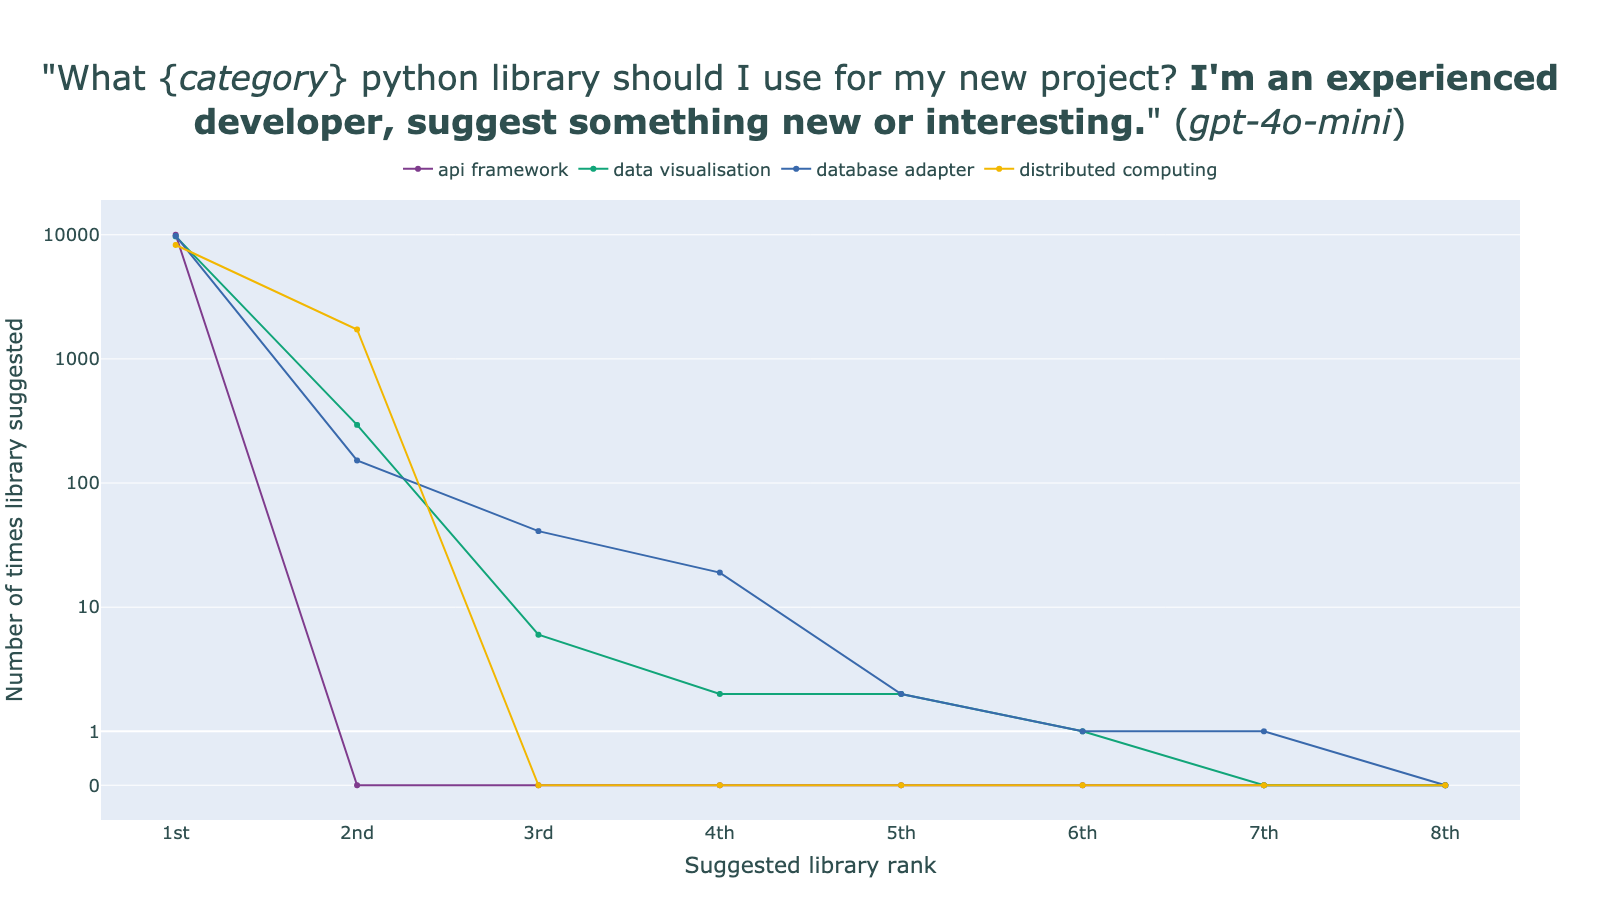

In [9]:
from src.plot import plot_line_results
from plotly_utils import write_and_display

base_fig = plot_line_results(
    data=base_data,
    title='"What {<i>category</i>} python library should I use for my new project?" (<i>gpt-4o-mini</i>)',
    x_title="Suggested library rank",
    y_title="Number of times library suggested",
    x_len=8,
)

write_and_display(
    figure=base_fig,
    name="suggest_py_base_gpt4omini",
    path="data/plots/",
    show=True,
)

exp_fig = plot_line_results(
    data=exp_data,
    title='"What {<i>category</i>} python library should I use for my new project? <b>I\'m an experienced<br>developer, suggest something new or interesting.</b>" (<i>gpt-4o-mini</i>)',
    x_title="Suggested library rank",
    y_title="Number of times library suggested",
    x_len=8,
)
write_and_display(
    figure=exp_fig,
    name="suggest_py_exp_gpt4omini",
    path="data/plots/",
    show=True,
)

In [10]:
from src.output import read_json

base_solve_raw = read_json("data/output/solve_language_mbpp.json")
base_solve_results = base_solve_raw["results"]["gpt-4o-mini"]["solutions"]

exp_solve_raw = read_json("data/output/solve_language_mbpp_exp.json")
exp_solve_results = exp_solve_raw["results"]["gpt-4o-mini"]["solutions"]

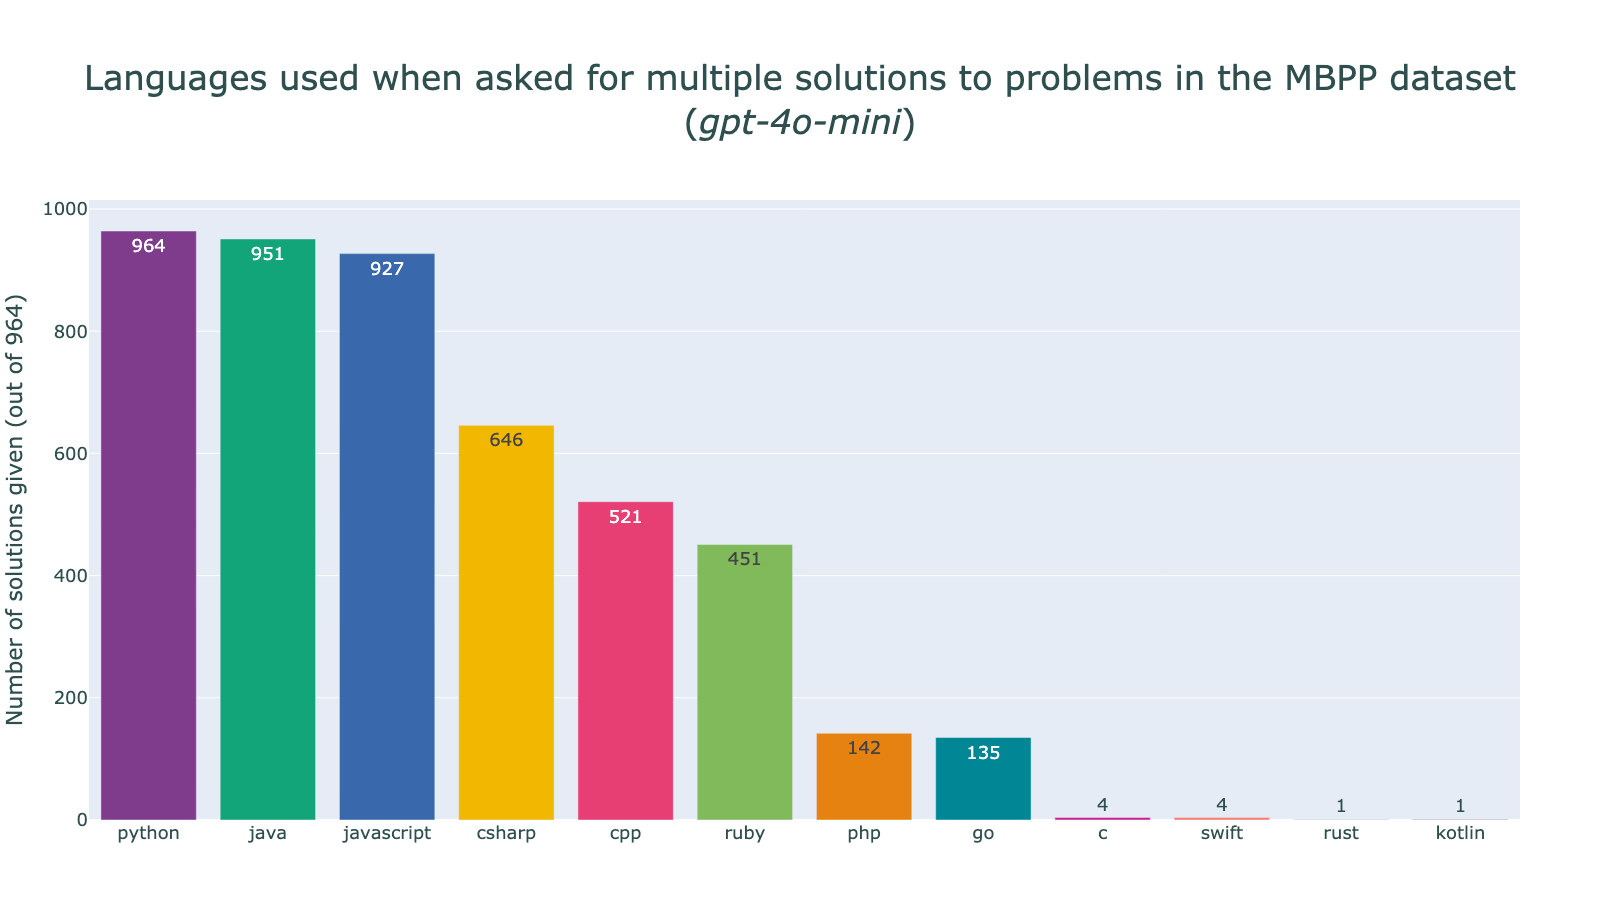

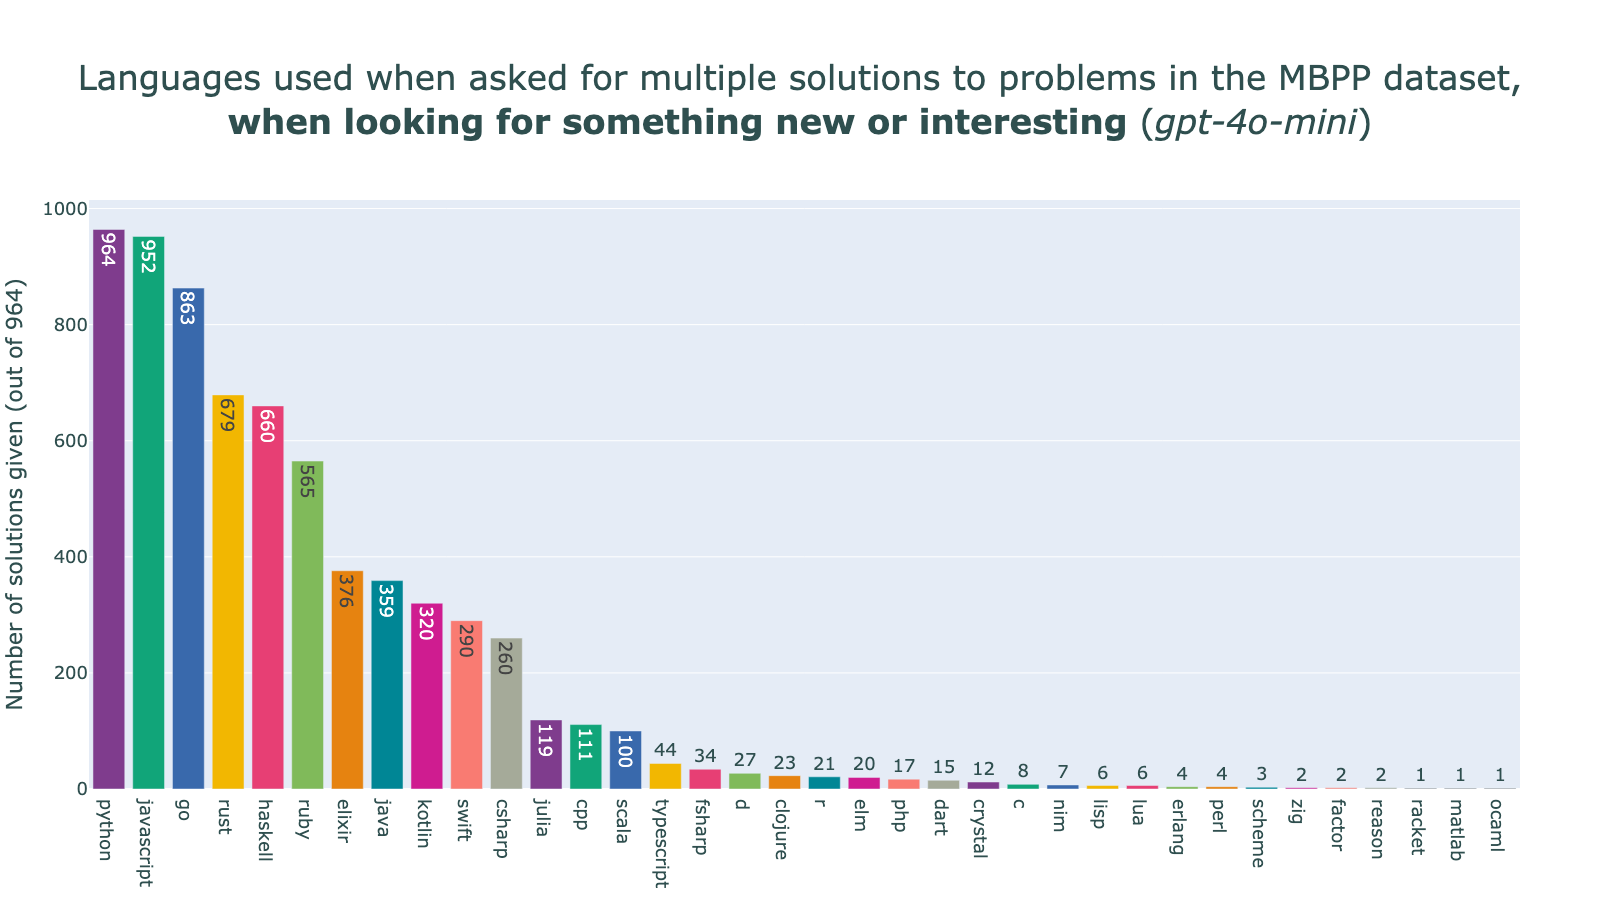

In [11]:
from src.plot import plot_bar_results
from plotly_utils import write_and_display

base_fig = plot_bar_results(
    data=base_solve_results,
    title="Languages used when asked for multiple solutions to problems in the MBPP dataset<br>(<i>gpt-4o-mini</i>)",
    descending=True,
    y_title="Number of solutions given (out of 964)",
)

write_and_display(
    figure=base_fig,
    name="solve_mbpp_base_gpt4omini",
    path="data/plots/",
    show=True,
)

exp_fig = plot_bar_results(
    data=exp_solve_results,
    title="Languages used when asked for multiple solutions to problems in the MBPP dataset,<br><b>when looking for something new or interesting</b> (<i>gpt-4o-mini</i>)",
    descending=True,
    y_title="Number of solutions given (out of 964)",
)

write_and_display(
    figure=exp_fig,
    name="solve_mbpp_exp_gpt4omini",
    path="data/plots/",
    show=True,
)

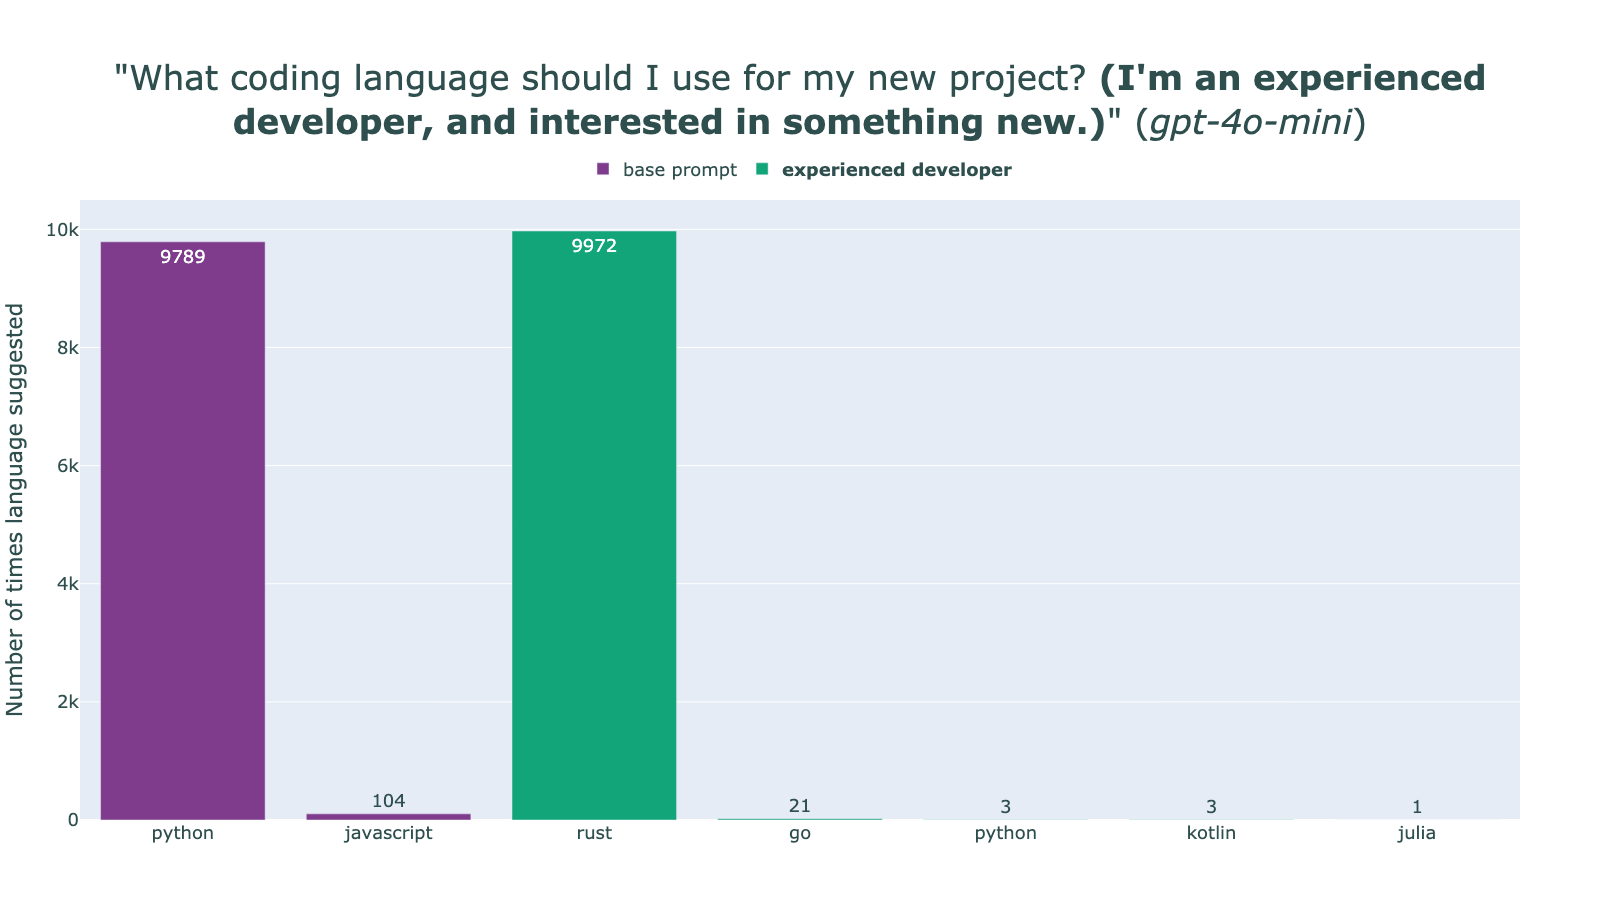

In [15]:
import plotly.graph_objects as go
from plotly_utils import default_figure, write_and_display
from src.plot import DEFAULT_COLOR_SCHEME


figure = default_figure(
    title='"What coding language should I use for my new project? <b>(I\'m an experienced<br>developer, and interested in something new.)</b>" (<i>gpt-4o-mini</i>)',
    y_title="Number of times language suggested",
    data=[
        go.Bar(
            x=["python", "javascript"],
            y=[9789, 104],
            text=[9789, 104],
            marker_color=DEFAULT_COLOR_SCHEME[0],
            name="base prompt",
        ),
        go.Bar(
            x=["rust", "go", " python ", "kotlin", "julia"],
            y=[9972, 21, 3, 3, 1],
            text=[9972, 21, 3, 3, 1],
            marker_color=DEFAULT_COLOR_SCHEME[1],
            name="<b>experienced developer</b>",
        ),
    ],
)

write_and_display(
    figure=figure,
    name="suggest_project_lang",
    path="data/plots/",
    show=True,
)